In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plot
import numpy as np
from sklearn.linear_model import LinearRegression

from sqlalchemy import engine
from pandasql import sqldf
pysqldf= lambda q: sqldf(q, globals())

In [3]:
import glob
import os

archivos = glob.glob("datos abiertos del gobierno/*.csv")

datos = {}
for archivo in archivos:
    nombre = os.path.basename(archivo).replace(".csv", "")
    datos[nombre] = pd.read_csv(archivo)

In [ ]:
datos["ied_pais_de_origen_sector"].head()

,pais_de_origen,sector_subsector_rama,anio,trimestre,fecha,millones_de_dolares,fn_millones_de_dolares
0,Alemania,"11 Agricultura, cría y explotación de animales...",2006,1,2006-03-01,0,0.0
1,Alemania,111 Agricultura,2006,1,2006-03-01,0,0.0
2,Alemania,"1111 Cultivo de semillas oleaginosas, legumino...",2006,1,2006-03-01,0,0.0
3,Alemania,1112 Cultivo de hortalizas,2006,1,2006-03-01,0,0.0
4,Alemania,1113 Cultivo de frutales y nueces,2006,1,2006-03-01,0,0.0


In [7]:
a= datos["tasa_neta_ocupacion_stps_2dotrim2025"]

In [8]:
# Filtrar Baja California y limpiar
bc = a[a["entidad_federativa"] == "Baja California"].copy()
bc = bc.dropna(subset=["tasa_neta_ocupacion"])

# Crear columna de fecha para graficar
bc["fecha"] = pd.to_datetime(bc["periodo"].astype(str) + "-" + 
              (bc["trimestre"] * 3).astype(str), format="%Y-%m")

print(f"Registros de BC: {len(bc)}")
print(bc.isnull().sum())

Registros de BC: 162
periodo                    0
trimestre                  0
entidad_federativa         0
sexo                       0
poblacion_ocupada          0
poblacion_edad_trabajar    0
tasa_neta_ocupacion        0
fecha                      0
dtype: int64


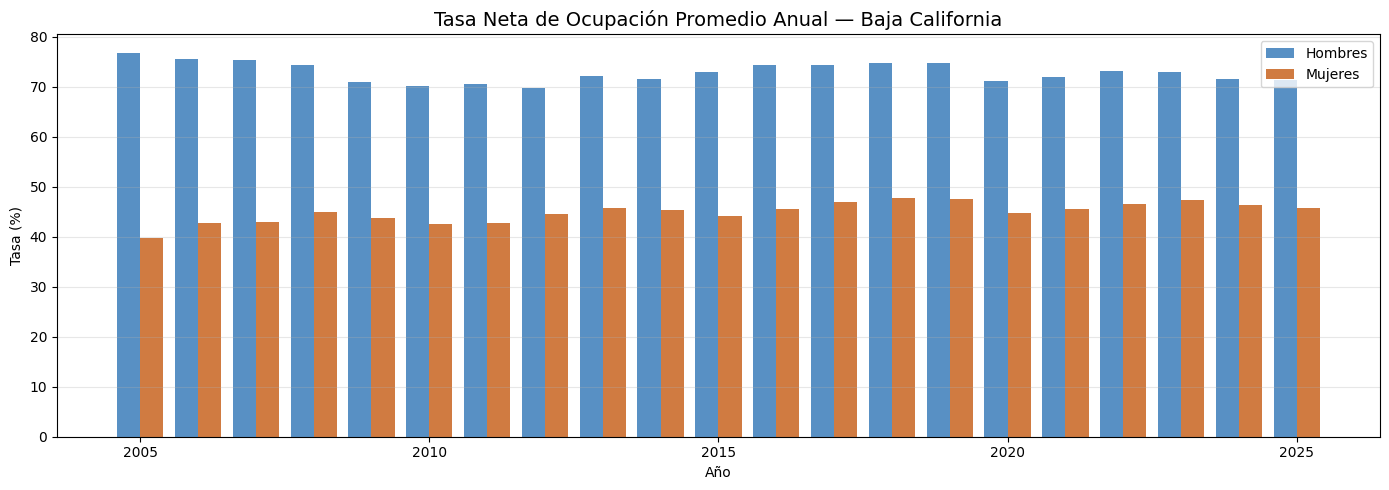

In [9]:
# Promedio por año
bc_anual = bc.groupby(["periodo", "sexo"])["tasa_neta_ocupacion"].mean().reset_index()

fig, ax = plot.subplots(figsize=(14, 5))
for sexo, color in [("Hombres", "#2E75B6"), ("Mujeres", "#C55A11")]:
    df_s = bc_anual[bc_anual["sexo"] == sexo]
    ax.bar(df_s["periodo"] + (0.2 if sexo == "Mujeres" else -0.2), 
           df_s["tasa_neta_ocupacion"], width=0.4, label=sexo, color=color, alpha=0.8)

ax.set_title("Tasa Neta de Ocupación Promedio Anual — Baja California", fontsize=14)
ax.set_ylabel("Tasa (%)")
ax.set_xlabel("Año")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plot.tight_layout()
plot.show()

In [10]:
print(bc[bc["sexo"] == "Hombres"].groupby("periodo")["trimestre"].count())

periodo
2005    4
2006    4
2007    4
2008    4
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    3
2021    4
2022    4
2023    4
2024    4
2025    2
Name: trimestre, dtype: int64


In [11]:
#Tipo de cambio:
tc = pd.read_csv(
    'Consulta_20260403-111246164.csv',
    skiprows=18,
    encoding='latin1',
    na_values=['N/E']   # Banxico usa N/E para datos no disponibles
)
# Renombrar solo las columnas que necesitamos
tc.columns = ["fecha", "SF60653", "fix", "apertura_compra", "apertura_venta",
              "cierre_compra", "cierre_venta", "maximo", "minimo", "historico", "cierre_jornada"]

# Convertir fecha y limpiar
tc["fecha"] = pd.to_datetime(tc["fecha"], format="%d/%m/%Y", dayfirst=True)
tc = tc[["fecha", "fix"]].dropna()

# Promedio anual
tc["periodo"] = tc["fecha"].dt.year
tc_anual = tc.groupby("periodo")["fix"].mean().reset_index()
tc_anual.columns = ["periodo", "tipo_cambio"]

print(tc_anual)

    periodo  tipo_cambio
0      2005    10.889503
1      2006    10.903372
2      2007    10.927441
3      2008    11.143810
4      2009    13.498305
5      2010    12.628694
6      2011    12.430060
7      2012    13.168949
8      2013    12.769568
9      2014    13.303180
10     2015    15.881004
11     2016    18.688619
12     2017    18.906590
13     2018    19.237266
14     2019    19.257390
15     2020    21.497606
16     2021    20.282220
17     2022    20.120460
18     2023    17.733837
19     2024    18.326316
20     2025    19.199553
21     2026    17.560334


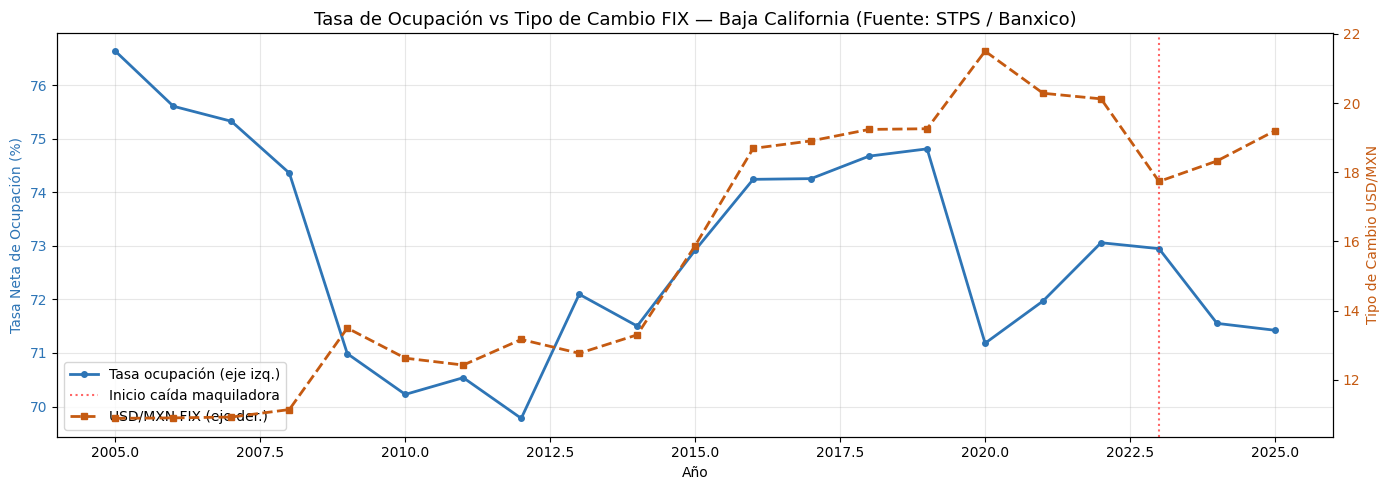


Correlación con datos reales de Banxico:
                     tasa_neta_ocupacion  tipo_cambio
tasa_neta_ocupacion             1.000000    -0.110556
tipo_cambio                    -0.110556     1.000000


In [12]:
# Unir con los datos de ocupación
bc_hombres_anual = bc[bc["sexo"] == "Hombres"].groupby("periodo")["tasa_neta_ocupacion"].mean().reset_index()
bc_merged = bc_hombres_anual.merge(tc_anual, on="periodo")
bc_merged["variacion"] = bc_merged["tasa_neta_ocupacion"].diff()

# Gráfica corregida con datos reales
fig, ax1 = plot.subplots(figsize=(14, 5))

ax1.plot(bc_merged["periodo"], bc_merged["tasa_neta_ocupacion"],
         color="#2E75B6", linewidth=2, marker="o", markersize=4, label="Tasa ocupación (eje izq.)")
ax1.set_ylabel("Tasa Neta de Ocupación (%)", color="#2E75B6")
ax1.tick_params(axis="y", labelcolor="#2E75B6")

ax2 = ax1.twinx()
ax2.plot(bc_merged["periodo"], bc_merged["tipo_cambio"],
         color="#C55A11", linewidth=2, linestyle="--", marker="s", markersize=4, label="USD/MXN FIX (eje der.)")
ax2.set_ylabel("Tipo de Cambio USD/MXN", color="#C55A11")
ax2.tick_params(axis="y", labelcolor="#C55A11")

ax1.axvline(2023, color="red", linestyle=":", alpha=0.6, label="Inicio caída maquiladora")
ax1.set_title("Tasa de Ocupación vs Tipo de Cambio FIX — Baja California (Fuente: STPS / Banxico)", fontsize=13)
ax1.set_xlabel("Año")
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plot.tight_layout()
plot.show()

# Correlación con datos reales
corr_real = bc_merged[["tasa_neta_ocupacion", "tipo_cambio"]].corr()
print("\nCorrelación con datos reales de Banxico:")
print(corr_real)

In [13]:
# Cargar INDPRO
indpro = pd.read_csv('INDPRO.csv')
indpro["observation_date"] = pd.to_datetime(indpro["observation_date"])
indpro["periodo"] = indpro["observation_date"].dt.year

# Promedio anual
indpro_anual = indpro.groupby("periodo")["INDPRO"].mean().reset_index()
indpro_anual.columns = ["periodo", "indpro"]

# Unir todo en un solo dataframe
bc_full = bc_merged.merge(indpro_anual, on="periodo")

In [14]:
# Correlación de todas las variables
print("Matriz de correlación completa:")
print(bc_full[["tasa_neta_ocupacion", "tipo_cambio", "indpro"]].corr().round(3))

Matriz de correlación completa:
                     tasa_neta_ocupacion  tipo_cambio  indpro
tasa_neta_ocupacion                1.000       -0.111   0.429
tipo_cambio                       -0.111        1.000   0.316
indpro                             0.429        0.316   1.000


In [16]:
# Cargar IED
ied = pd.read_csv('C:/Users/Joel/AppData/Local/Programs/Python/Python314/ied_entidad_pais_de_origen.csv', encoding='utf-8-sig')

# Filtrar solo Baja California (total de todos los países)
ied_bc = ied[ied["entidad"] == "Baja California"].groupby("anio")["millones_de_dolares"].sum().reset_index()
ied_bc.columns = ["periodo", "ied_bc"]

print(ied_bc)

    periodo       ied_bc
0      2006  1340.691610
1      2007  1790.829226
2      2008  1454.140673
3      2009   829.523190
4      2010  1414.822950
5      2011   766.322327
6      2012  1018.518951
7      2013  1290.826481
8      2014  1223.344367
9      2015  1167.278445
10     2016  1567.130437
11     2017  1678.948897
12     2018  1631.150229
13     2019  1183.728077
14     2020  1195.390076
15     2021  2222.726169
16     2022  1874.377235
17     2023  1477.046078
18     2024  1809.065877


In [17]:
bc_completo = bc_merged.merge(indpro_anual, on="periodo")
bc_completo = bc_completo.merge(ied_bc, on="periodo")


# Filtrar años disponibles en todas las fuentes (2006-2024)
bc_completo = bc_completo[bc_completo["periodo"] >= 2006].reset_index(drop=True)

print(f"Dataset completo: {bc_completo.shape}")
print(bc_completo.head())

Dataset completo: (19, 6)
   periodo  tasa_neta_ocupacion  tipo_cambio  variacion      indpro  \
0     2006            75.606421    10.903372  -1.027659   98.995317   
1     2007            75.325659    10.927441  -0.280762  101.571992   
2     2008            74.358605    11.143810  -0.967054   98.117275   
3     2009            70.987078    13.498305  -3.371526   86.899625   
4     2010            70.225831    12.628694  -0.761247   91.737033   

        ied_bc  
0  1340.691610  
1  1790.829226  
2  1454.140673  
3   829.523190  
4  1414.822950  


In [19]:
bc_completo

,periodo,tasa_neta_ocupacion,tipo_cambio,variacion,indpro,ied_bc
0,2006,75.606421,10.903372,-1.027659,98.995317,1340.691610
1,2007,75.325659,10.927441,-0.280762,101.571992,1790.829226
2,2008,74.358605,11.143810,-0.967054,98.117275,1454.140673
3,2009,70.987078,13.498305,-3.371526,86.899625,829.523190
4,2010,70.225831,12.628694,-0.761247,91.737033,1414.822950
5,2011,70.538321,12.430060,0.312489,94.639558,766.322327
6,2012,69.778694,13.168949,-0.759627,97.540858,1018.518951
7,2013,72.095495,12.769568,2.316801,99.484375,1290.826481
8,2014,71.501733,13.303180,-0.593762,102.447650,1223.344367
9,2015,72.919265,15.881004,1.417532,100.971950,1167.278445


In [20]:
bc_completo.to_csv("bc_completo.csv", index=False)